---
title: "2. Modelo final con validación segura"
---

# Proyecto Integrador — Heart Failure Prediction

## Nombres: Juan Camilo Oñoro Araujo - 200177329 y María Carolina Cantillo Orozco - 200179105
## Fecha: 30/09/2026

## MACHINE LEARNING

Notebook 2 — Etapa 2: Modelado con validación segura

Este cuaderno contiene:

1. División de los datos antes del escalado.
2. Implementación de Pipeline con GridSearchCV.
3. Evaluación del modelo con matriz de confusión, curva ROC y AUC.

Las decisiones de preprocesamiento vienen del EDA del notebook 1 (Parte 25).



En el notebook 1 se compararon modelos. Aquí se construye el modelo definitivo, el que va a usar la API.

Se separan los datos, se elige el modelo solo con validación cruzada, se evalúa una única vez con el conjunto de prueba y se guarda el Pipeline completo. Si el conjunto de prueba se usara para tomar decisiones, dejaría de ser una evaluación honesta de cómo se comportará el modelo con pacientes nuevos.

Parte 1. Librerías y configuraciones

In [1]:
import os
# joblib no puede contar los núcleos físicos en este Windows y lanza un aviso; se le indica cuántos usar
os.environ["LOKY_MAX_CPU_COUNT"] = str(max(1, (os.cpu_count() or 2) // 2))

import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from IPython.display import display

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

SEED = 42
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | joblib {joblib.__version__}")

pandas 2.1.0 | numpy 1.25.2 | scikit-learn 1.3.0 | joblib 1.3.2


In [2]:
COLOR = {
    "principal":  "#2a78d6",
    "secundario": "#eb6834",
    "texto":      "#0b0b0b",
    "texto_2":    "#52514e",
    "tenue":      "#898781",
    "rejilla":    "#e1e0d9",
    "eje":        "#c3c2b7",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Calibri", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.labelcolor": COLOR["texto_2"],
    "axes.edgecolor": COLOR["eje"],
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR["rejilla"],
    "grid.linewidth": 0.6,
    "xtick.color": COLOR["texto_2"],
    "ytick.color": COLOR["texto_2"],
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "text.color": COLOR["texto"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

CLASE_COLOR = {0: COLOR["principal"], 1: COLOR["secundario"]}
CLASE_NOMBRE = {0: "Sin enfermedad", 1: "Con enfermedad"}
CMAP_SEC = LinearSegmentedColormap.from_list("azul", ["#f7f9fc", "#9ec5f4", "#2a78d6", "#0d366b"])


def titulo_figura(fig, texto):
    fig.suptitle(texto, x=0.01, ha="left", fontsize=13, fontweight="semibold")

Parte 2. Carga de datos y rutas del proyecto

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
APP_DIR = ROOT / "app"
FIG_DIR = ROOT / "figuras"
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "heart.csv")

TARGET = "HeartDisease"
X = df.drop(columns=TARGET)
y = df[TARGET]
print(f"{len(df)} pacientes | {X.shape[1]} variables | {y.mean():.1%} con enfermedad")
display(X.head(3))

918 pacientes | 11 variables | 55.3% con enfermedad


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0000,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0000,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0000,Up


Parte 3. División de los datos antes del escalado

El split se hace sobre los datos crudos, antes de calcular cualquier estadística. A partir de aquí el conjunto de prueba queda guardado y solo se usa en la Parte 8. Se usa el mismo split estratificado 80/20 y la misma semilla del notebook 1, para que los resultados se puedan comparar.

Los dos conjuntos se guardan en data/: train.csv servirá como referencia para el monitoreo de deriva de la Etapa 6.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

display(pd.DataFrame({
    "n": [len(y_train), len(y_test)],
    "pct_con_enfermedad": [y_train.mean() * 100, y_test.mean() * 100],
    "ceros_cholesterol": [(X_train["Cholesterol"] == 0).sum(), (X_test["Cholesterol"] == 0).sum()],
}, index=["train", "test"]).style.format({"pct_con_enfermedad": "{:.2f} %"}))

pd.concat([X_train, y_train], axis=1).to_csv(DATA_DIR / "train.csv", index=False)
pd.concat([X_test, y_test], axis=1).to_csv(DATA_DIR / "test.csv", index=False)
print(f"Guardados: {DATA_DIR / 'train.csv'} y {DATA_DIR / 'test.csv'}")

,n,pct_con_enfermedad,ceros_cholesterol
train,734,55.31 %,129
test,184,55.43 %,43


Guardados: E:\Documents\MachineLearningUN\heart-disease-mlops\data\train.csv y E:\Documents\MachineLearningUN\heart-disease-mlops\data\test.csv


Si el escalador se ajustara con todo el dataset, el mínimo y el máximo incluirían pacientes de prueba. Con el split primero, el escalador solo conoce train. La tabla compara los parámetros que aprendería MinMaxScaler en cada caso.

In [5]:
COLS_NUM = ["Age", "MaxHR", "Oldpeak"]
comparacion = pd.DataFrame({
    "min_train": X_train[COLS_NUM].min(), "min_todo": X[COLS_NUM].min(),
    "max_train": X_train[COLS_NUM].max(), "max_todo": X[COLS_NUM].max(),
})
comparacion["¿igual?"] = np.where((comparacion["min_train"] == comparacion["min_todo"])
                                  & (comparacion["max_train"] == comparacion["max_todo"]), "Sí", "No")
display(comparacion)

# Consecuencia: en test pueden aparecer valores fuera del rango [0, 1] después de escalar, y eso es correcto
escalador = MinMaxScaler().fit(X_train[COLS_NUM])
X_test_esc = pd.DataFrame(escalador.transform(X_test[COLS_NUM]), columns=COLS_NUM)
print("Rango de test después de escalar con los parámetros de train:")
display(X_test_esc.agg(["min", "max"]))

,min_train,min_todo,max_train,max_todo,¿igual?
Age,29.0000,28.0000,77.0000,77.0000,No
MaxHR,60.0000,60.0000,202.0000,202.0000,Sí
Oldpeak,-2.6000,-2.6000,5.6000,6.2000,No


Rango de test después de escalar con los parámetros de train:


,Age,MaxHR,Oldpeak
min,-0.0208,0.1408,0.3049
max,0.9583,0.9507,1.0732


Los parámetros del escalador sí cambian según el orden. Con el split primero, el mínimo de age es 29 y no 28, y el máximo de oldpeak es 5.6 y no 6.2, porque el paciente de 28 años y el de oldpeak 6.2 quedaron en test. Si se escalara con todo el dataset, el modelo tendría información sobre esos pacientes de prueba antes de evaluarlos.

Por eso, en test aparecen valores escalados fuera de [0, 1]: −0.02 en age y 1.07 en oldpeak. No es un error. Es exactamente lo que pasará en producción cuando llegue un paciente con valores más extremos que los de entrenamiento.

Parte 4. Preprocesador para producción

En el notebook 1 los ceros imposibles se convertían en NaN antes del Pipeline. Aquí ese paso va dentro del Pipeline, con SimpleImputer(missing_values=0): el imputador trata directamente el 0 como faltante. Así el modelo exportado recibe los datos tal como los envía el usuario, y la API no tiene que repetir ninguna limpieza a mano.

| Grupo | Columnas | Tratamiento |
|---|---|---|
| num | age, maxhr, oldpeak | MinMaxScaler |
| num_ceros | restingbp, cholesterol | 0 → mediana de train + indicador de faltante, y después MinMaxScaler |
| cat | sex, chestpaintype, restingecg, exerciseangina, st_slope | OneHotEncoder(handle_unknown="ignore") |
| bin | fastingbs | Sin cambios |

In [6]:
COLS_ESCALAR = ["Age", "MaxHR", "Oldpeak"]
COLS_CEROS = ["RestingBP", "Cholesterol"]
COLS_ONEHOT = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
COLS_BINARIAS = ["FastingBS"]
COLUMNAS_ENTRADA = list(X.columns)          # orden en que el modelo espera las variables


def crear_preprocesador():
    return ColumnTransformer([
        ("num", MinMaxScaler(), COLS_ESCALAR),
        ("num_ceros", Pipeline([
            ("imputar", SimpleImputer(missing_values=0, strategy="median", add_indicator=True)),
            ("escalar", MinMaxScaler()),
        ]), COLS_CEROS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_ONEHOT),
        ("bin", "passthrough", COLS_BINARIAS),
    ], verbose_feature_names_out=False)


prep = crear_preprocesador().fit(X_train)
print(f"Variables de salida ({len(prep.get_feature_names_out())}):")
print(list(prep.get_feature_names_out()))
print("Medianas aprendidas con train:", dict(zip(COLS_CEROS, prep.named_transformers_["num_ceros"]["imputar"].statistics_)))

Variables de salida (21):
['Age', 'MaxHR', 'Oldpeak', 'RestingBP', 'Cholesterol', 'missingindicator_Cholesterol', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'FastingBS']
Medianas aprendidas con train: {'RestingBP': 130.0, 'Cholesterol': 238.0}


Parte 5. Pipeline con GridSearchCV

En lugar de una búsqueda por modelo, se hace una sola búsqueda en la que el propio clasificador también es un hiperparámetro. El paso "clf" del Pipeline se reemplaza por cada candidato, y GridSearchCV prueba todas las combinaciones con la misma validación cruzada de 5 folds. Así todos los modelos se comparan exactamente en las mismas condiciones.

Los candidatos son los 5 mejores del notebook 1. Se descartan el árbol de decisión y Naive Bayes, que quedaron claramente por debajo. Las grillas son las mismas del notebook 1. Se registran AUC y Accuracy, y el mejor modelo se elige por AUC.

In [7]:
pipe = Pipeline([("prep", crear_preprocesador()), ("clf", LogisticRegression())])

param_grid = [
    {"clf": [LogisticRegression(max_iter=5000, solver="liblinear", random_state=SEED)],
     "clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]},
    {"clf": [SVC(probability=True, random_state=SEED)],
     "clf__C": [0.1, 1, 10, 100], "clf__gamma": ["scale", 0.01, 0.1]},
    {"clf": [KNeighborsClassifier()],
     "clf__n_neighbors": [5, 11, 21, 31, 51, 71, 101], "clf__weights": ["uniform", "distance"], "clf__p": [1, 2]},
    {"clf": [RandomForestClassifier(n_estimators=300, random_state=SEED)],
     "clf__max_depth": [None, 5, 10], "clf__min_samples_leaf": [1, 3, 5], "clf__max_features": ["sqrt", 0.5]},
    {"clf": [GradientBoostingClassifier(random_state=SEED)],
     "clf__n_estimators": [100, 300], "clf__learning_rate": [0.01, 0.03, 0.1],
     "clf__max_depth": [2, 3], "clf__subsample": [0.8, 1.0]},
]

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(pipe, param_grid, cv=CV, scoring={"AUC": "roc_auc", "Accuracy": "accuracy"},
                    refit="AUC", n_jobs=-1, return_train_score=True)

t0 = time.time()
grid.fit(X_train, y_train)
print(f"{len(grid.cv_results_['params'])} combinaciones x 5 folds = {len(grid.cv_results_['params']) * 5} ajustes "
      f"en {time.time() - t0:.1f} s")
print(f"Mejor modelo: {type(grid.best_params_['clf']).__name__}")
print(f"Mejores hiperparámetros: { {k.replace('clf__', ''): v for k, v in grid.best_params_.items() if k != 'clf'} }")
print(f"AUC CV del mejor: {grid.best_score_:.4f}")

90 combinaciones x 5 folds = 450 ajustes en 12.8 s
Mejor modelo: RandomForestClassifier
Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}
AUC CV del mejor: 0.9343


Parte 6. Selección del modelo por validación cruzada

Para cada familia de modelos se muestra su mejor combinación. El orden es por AUC de validación cruzada, sin usar el conjunto de prueba.

In [8]:
resultados = pd.DataFrame(grid.cv_results_)
resultados["modelo"] = resultados["param_clf"].apply(lambda m: type(m).__name__)
resultados["hiperparametros"] = resultados["params"].apply(
    lambda p: {k.replace("clf__", ""): v for k, v in p.items() if k != "clf"})

mejores = (resultados.sort_values("mean_test_AUC", ascending=False).groupby("modelo").head(1)
           .set_index("modelo")[["mean_test_AUC", "std_test_AUC", "mean_test_Accuracy", "std_test_Accuracy",
                                 "mean_train_AUC", "hiperparametros"]])
mejores["brecha_train_CV"] = mejores["mean_train_AUC"] - mejores["mean_test_AUC"]
mejores.insert(0, "puesto", range(1, len(mejores) + 1))
display(mejores.drop(columns="mean_train_AUC").style.format(
    {c: "{:.4f}" for c in ["mean_test_AUC", "std_test_AUC", "mean_test_Accuracy", "std_test_Accuracy", "brecha_train_CV"]}))

# AUC de cada fold para el mejor de cada familia (los folds son los mismos para todos)
folds = pd.DataFrame({m: resultados.loc[resultados.loc[resultados["modelo"] == m, "mean_test_AUC"].idxmax(),
                                        [f"split{k}_test_AUC" for k in range(5)]].values.astype(float)
                      for m in mejores.index}, index=[f"fold {k + 1}" for k in range(5)])
display(folds.style.format("{:.4f}").highlight_max(axis=1, props=f"background-color: {COLOR['secundario']}; color: white"))

# ¿El ganador es significativamente mejor que el segundo? Prueba t pareada sobre los 5 folds
primero, segundo = mejores.index[:2]
t_stat, p_t = stats.ttest_rel(folds[primero], folds[segundo])
print(f"{primero} vs {segundo}: diferencia media = {(folds[primero] - folds[segundo]).mean():+.4f}, "
      f"t pareada p = {p_t:.3f}")

,puesto,mean_test_AUC,std_test_AUC,mean_test_Accuracy,std_test_Accuracy,hiperparametros,brecha_train_CV
modelo,,,,,,,
RandomForestClassifier,1,0.9343,0.0265,0.8638,0.0423,"{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}",0.0391
GradientBoostingClassifier,2,0.9329,0.0245,0.8597,0.0233,"{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}",0.0381
LogisticRegression,3,0.9292,0.0370,0.8570,0.0359,"{'C': 1, 'penalty': 'l2'}",0.0070
KNeighborsClassifier,4,0.9273,0.0324,0.8638,0.0294,"{'n_neighbors': 51, 'p': 2, 'weights': 'distance'}",0.0727
SVC,5,0.9269,0.0360,0.8638,0.0401,"{'C': 1, 'gamma': 0.1}",0.0147


,RandomForestClassifier,GradientBoostingClassifier,LogisticRegression,KNeighborsClassifier,SVC
fold 1,0.9315,0.9289,0.9266,0.9270,0.9118
fold 2,0.8851,0.8874,0.8614,0.8682,0.8642
fold 3,0.9502,0.9489,0.9473,0.9398,0.9474
fold 4,0.9622,0.9572,0.9719,0.9667,0.9669
fold 5,0.9423,0.9419,0.9388,0.9347,0.9440


RandomForestClassifier vs GradientBoostingClassifier: diferencia media = +0.0014, t pareada p = 0.304


RandomForest es el mejor por AUC de validación cruzada (0.9343), seguido muy de cerca por GradientBoosting (0.9329). La diferencia entre los dos es de +0.0014 y no es significativa (t pareada sobre los 5 folds, p = 0.304). Después vienen la regresión logística (0.9292), KNN (0.9273) y SVC (0.9269). Los cinco quedan en un rango de 0.008 de AUC.

La tabla de folds muestra que la variación entre folds es mucho mayor que entre modelos. El fold 2 es difícil para todos (AUC entre 0.861 y 0.887) y el fold 4 es fácil para todos (entre 0.957 y 0.972). Ningún modelo es mejor en todos los folds.

Se elige RandomForest (max_depth = None, max_features = sqrt, min_samples_leaf = 5) porque es el primero por el criterio fijado de antemano (AUC de CV), no porque sea claramente superior. Su brecha train–CV (0.039) es moderada: min_samples_leaf = 5 evita que los árboles memoricen cada paciente.

Parte 7. Validación cruzada anidada

El AUC de la Parte 6 (grid.best_score_) es un poco optimista, porque es el máximo entre 90 combinaciones evaluadas con los mismos folds. La validación cruzada anidada estima cuánto rinde el procedimiento completo (buscar hiperparámetros y elegir el modelo):

1. El bucle externo (5 folds) separa datos que la búsqueda nunca ve.
2. El bucle interno es el mismo GridSearchCV de la Parte 5.

Todo se hace dentro de train, así que el conjunto de prueba sigue sin usarse.

In [9]:
CV_EXTERNO = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
grid_interno = GridSearchCV(pipe, param_grid, cv=CV, scoring="roc_auc", n_jobs=-1)

t0 = time.time()
anidada = cross_validate(grid_interno, X_train, y_train, cv=CV_EXTERNO, scoring=["roc_auc", "accuracy"],
                         return_estimator=True, n_jobs=1)
print(f"Validación anidada en {time.time() - t0:.1f} s")

tabla_anidada = pd.DataFrame({
    "AUC": anidada["test_roc_auc"],
    "Accuracy": anidada["test_accuracy"],
    "modelo_elegido": [type(e.best_params_["clf"]).__name__ for e in anidada["estimator"]],
}, index=[f"fold externo {k + 1}" for k in range(5)])
display(tabla_anidada.style.format({"AUC": "{:.4f}", "Accuracy": "{:.4f}"}))
print(f"AUC anidado     : {anidada['test_roc_auc'].mean():.4f} ± {anidada['test_roc_auc'].std():.4f}")
print(f"Accuracy anidado: {anidada['test_accuracy'].mean():.4f} ± {anidada['test_accuracy'].std():.4f}")
print(f"AUC de la búsqueda simple (Parte 5): {grid.best_score_:.4f}")

Validación anidada en 56.9 s


,AUC,Accuracy,modelo_elegido
fold externo 1,0.9311,0.8571,RandomForestClassifier
fold externo 2,0.9057,0.8503,RandomForestClassifier
fold externo 3,0.9345,0.8571,RandomForestClassifier
fold externo 4,0.9213,0.8435,GradientBoostingClassifier
fold externo 5,0.9387,0.8356,GradientBoostingClassifier


AUC anidado     : 0.9263 ± 0.0118
Accuracy anidado: 0.8488 ± 0.0083
AUC de la búsqueda simple (Parte 5): 0.9343


La validación anidada da AUC = 0.9263 ± 0.0118, un poco por debajo del 0.9343 de la búsqueda simple. La diferencia (0.008) es el optimismo de escoger el máximo entre 90 combinaciones evaluadas con los mismos folds. 0.926 es la estimación honesta de cuánto rinde el procedimiento completo con datos nuevos.

En los 5 folds externos, la búsqueda interna eligió RandomForest 3 veces y GradientBoosting 2 veces. Esto confirma que los dos están empatados y que la elección entre ellos depende de qué pacientes caen en cada fold. El Accuracy anidado es 0.849 ± 0.008.

Parte 8. Evaluación final en el conjunto de prueba

El modelo elegido ya está reentrenado con todo train (refit=True). Se evalúa una sola vez con los 184 pacientes de prueba, que no participaron en ninguna decisión anterior. Se usa el umbral de 0.5, el mismo que usará la API.

In [10]:
modelo_final = grid.best_estimator_
proba_test = modelo_final.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
metricas_test = {
    "AUC": roc_auc_score(y_test, proba_test),
    "Accuracy": accuracy_score(y_test, pred_test),
    "Precision": precision_score(y_test, pred_test),
    "Recall (sensibilidad)": recall_score(y_test, pred_test),
    "Especificidad": tn / (tn + fp),
    "F1": f1_score(y_test, pred_test),
}

# Intervalo de confianza del AUC con bootstrap (2,000 remuestreos del conjunto de prueba)
rng = np.random.default_rng(SEED)
auc_boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_test), len(y_test))
    if y_test.iloc[idx].nunique() == 2:
        auc_boot.append(roc_auc_score(y_test.iloc[idx], proba_test[idx]))
ic_inf, ic_sup = np.percentile(auc_boot, [2.5, 97.5])

display(pd.Series(metricas_test, name=type(modelo_final.named_steps["clf"]).__name__).to_frame().T
        .style.format("{:.4f}"))
print(f"AUC test = {metricas_test['AUC']:.4f}  (IC 95 % bootstrap: {ic_inf:.4f} – {ic_sup:.4f})")
print(f"Verdaderos negativos = {tn} | Falsos positivos = {fp} | Falsos negativos = {fn} | Verdaderos positivos = {tp}")
print()
print(classification_report(y_test, pred_test, target_names=[CLASE_NOMBRE[0], CLASE_NOMBRE[1]], digits=4))

,AUC,Accuracy,Precision,Recall (sensibilidad),Especificidad,F1
RandomForestClassifier,0.9341,0.8913,0.8727,0.9412,0.8293,0.9057


AUC test = 0.9341  (IC 95 % bootstrap: 0.8929 – 0.9682)
Verdaderos negativos = 68 | Falsos positivos = 14 | Falsos negativos = 6 | Verdaderos positivos = 96

                precision    recall  f1-score   support

Sin enfermedad     0.9189    0.8293    0.8718        82
Con enfermedad     0.8727    0.9412    0.9057       102

      accuracy                         0.8913       184
     macro avg     0.8958    0.8852    0.8887       184
  weighted avg     0.8933    0.8913    0.8906       184



Matriz de confusión

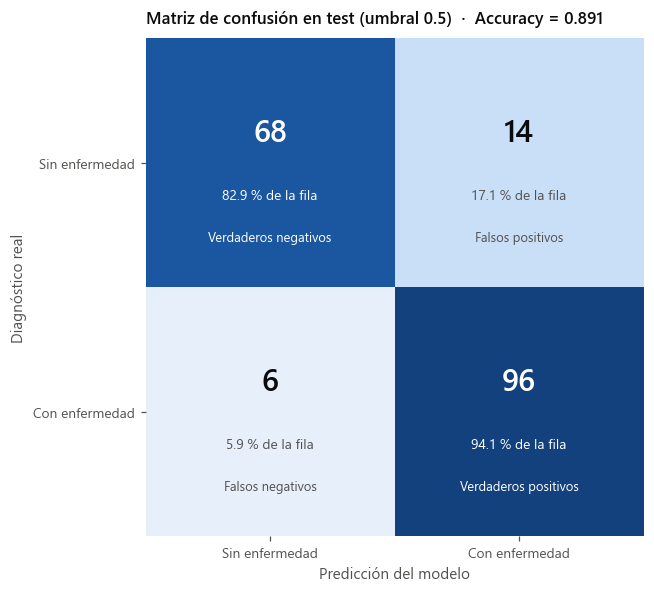

In [11]:
cm = confusion_matrix(y_test, pred_test)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
etiquetas = [CLASE_NOMBRE[0], CLASE_NOMBRE[1]]
nombres_celda = [["Verdaderos negativos", "Falsos positivos"], ["Falsos negativos", "Verdaderos positivos"]]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm_pct, cmap=CMAP_SEC, vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        claro = cm_pct[i, j] > 55
        ax.text(j, i - 0.12, f"{cm[i, j]}", ha="center", va="center", fontsize=20, fontweight="semibold",
                color="white" if claro else COLOR["texto"])
        ax.text(j, i + 0.13, f"{cm_pct[i, j]:.1f} % de la fila", ha="center", va="center", fontsize=9,
                color="white" if claro else COLOR["texto_2"])
        ax.text(j, i + 0.3, nombres_celda[i][j], ha="center", va="center", fontsize=8.5,
                color="white" if claro else COLOR["texto_2"])
ax.set_xticks([0, 1], etiquetas)
ax.set_yticks([0, 1], etiquetas)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Diagnóstico real")
ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(False)
ax.set_title(f"Matriz de confusión en test (umbral 0.5)  ·  Accuracy = {metricas_test['Accuracy']:.3f}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_matriz_confusion.png")
plt.show()

Se observa que la cantidad de falsos negativos esla mejor, lo cual tiene sentido, poruqe en el entorno médico se prefiere dar un tratamiento a alguien, aún si no tiene la enfermedad. SIn embargo, tampco ose quiere un modelo que diga siempre que sí la tienes, porque eso implica costos y otros riesgos adicionales como efectos secundarios de medicamentos. 

Curva ROC y AUC

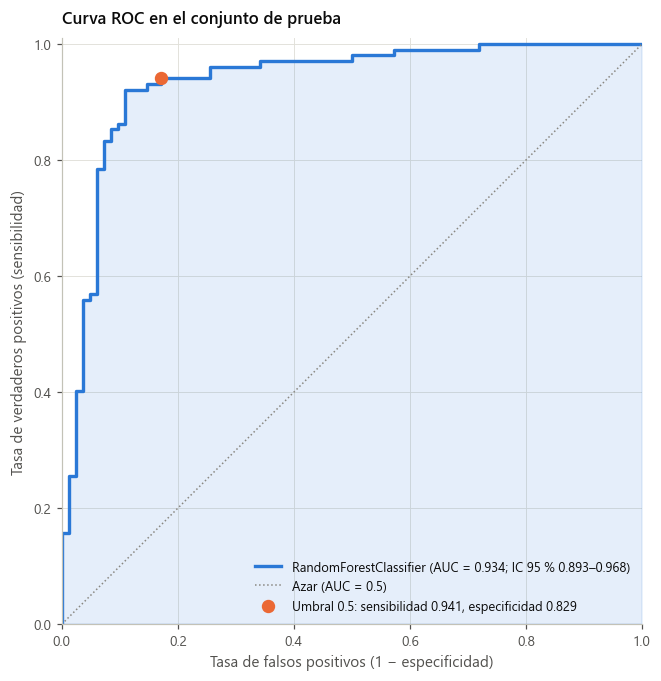

In [12]:
fpr, tpr, umbrales = roc_curve(y_test, proba_test)
i05 = np.argmin(np.abs(umbrales - 0.5))

fig, ax = plt.subplots(figsize=(6.8, 6.3))
ax.fill_between(fpr, tpr, step="post", color=COLOR["principal"], alpha=0.12)
ax.step(fpr, tpr, where="post", color=COLOR["principal"], linewidth=2.2,
        label=f"{type(modelo_final.named_steps['clf']).__name__} (AUC = {metricas_test['AUC']:.3f}; "
              f"IC 95 % {ic_inf:.3f}–{ic_sup:.3f})")
ax.plot([0, 1], [0, 1], color=COLOR["tenue"], linestyle=":", linewidth=1, label="Azar (AUC = 0.5)")
ax.scatter(fpr[i05], tpr[i05], s=60, color=COLOR["secundario"], zorder=3,
           label=f"Umbral 0.5: sensibilidad {tpr[i05]:.3f}, especificidad {1 - fpr[i05]:.3f}")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=8.5)
ax.set_title("Curva ROC en el conjunto de prueba")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_curva_roc.png")
plt.show()

En los 184 pacientes de prueba, el modelo obtiene AUC = 0.934, con un intervalo de confianza del 95 % por bootstrap de 0.893 a 0.968, y Accuracy = 0.891. El AUC de test coincide con el de validación cruzada (0.934) y queda dentro del rango de la validación anidada. No hay señales de sobreajuste en la selección.

En la matriz de confusión, con umbral 0.5:

1. Detecta 96 de los 102 enfermos (sensibilidad 0.941). Solo hay 6 falsos negativos, que son el error más grave en un tamizaje cardíaco, porque es un paciente enfermo que se va a casa sin tratamiento.
2. Hay 14 falsos positivos de 82 sanos (especificidad 0.829). Es el punto débil del modelo: como se señaló en el notebook 1, un falso positivo puede llevar a tratamientos innecesarios.

El intervalo de confianza es amplio (±0.04) porque el conjunto de prueba es pequeño. Por eso las diferencias de 0.003 a 0.008 entre modelos del notebook 1 no permiten decir que uno sea mejor que otro.

No vale la pena tener una sensibilidad más alta, ya que subirían los falsos positivos, se tiene una sensibilidad bastante buena para un modelo general, sin embargo, se podría mejorar si se tuviesen más datos o si se hicieran más preguntas clave en el dataset, como hacer o no ejericio,fumar o no, beber alcohol o no. 

Parte 9. Umbral de decisión

La API usa 0.5, igual que el enunciado, pero el umbral es una decisión clínica: bajarlo detecta más enfermos a cambio de más falsos positivos, y subirlo hace lo contrario. Para elegir un umbral alternativo sin tocar test, se usan las probabilidades fuera de fold de train (cross_val_predict) y el índice de Youden (sensibilidad + especificidad − 1). Después se muestra cómo se comportan varios umbrales en test.

In [13]:
proba_oof = cross_val_predict(modelo_final, X_train, y_train, cv=CV, method="predict_proba", n_jobs=-1)[:, 1]
fpr_tr, tpr_tr, umb_tr = roc_curve(y_train, proba_oof)
umbral_youden = float(umb_tr[np.argmax(tpr_tr - fpr_tr)])
print(f"Umbral de Youden (elegido con train, fuera de fold): {umbral_youden:.3f}")

filas = []
for u in sorted({0.3, 0.4, 0.5, 0.6, 0.7, round(umbral_youden, 3)}):
    p = (proba_test >= u).astype(int)
    tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test, p).ravel()
    filas.append({"umbral": u, "origen": "Youden (train)" if u == round(umbral_youden, 3) else "",
                  "sensibilidad": tp_u / (tp_u + fn_u), "especificidad": tn_u / (tn_u + fp_u),
                  "accuracy": (tp_u + tn_u) / len(p), "falsos_positivos": fp_u, "falsos_negativos": fn_u})
display(pd.DataFrame(filas).set_index("umbral").style.format(
    {"sensibilidad": "{:.3f}", "especificidad": "{:.3f}", "accuracy": "{:.3f}"}))

Umbral de Youden (elegido con train, fuera de fold): 0.550


,origen,sensibilidad,especificidad,accuracy,falsos_positivos,falsos_negativos
umbral,,,,,,
0.300000,,0.961,0.683,0.837,26,4
0.400000,,0.941,0.780,0.870,18,6
0.500000,,0.941,0.829,0.891,14,6
0.550000,Youden (train),0.922,0.866,0.897,11,8
0.600000,,0.863,0.890,0.875,9,14
0.700000,,0.775,0.939,0.848,5,23


El umbral de Youden, elegido con las predicciones fuera de fold de train, es 0.55. En test, frente a 0.5, reduce los falsos positivos de 14 a 11 (especificidad de 0.829 a 0.866) a cambio de 2 falsos negativos más (de 6 a 8), y sube el accuracy de 0.891 a 0.897.

La tabla muestra el compromiso:

1. Con 0.3 solo quedan 4 falsos negativos, pero hay 26 falsos positivos.
2. Con 0.7 solo hay 5 falsos positivos, pero se escapan 23 enfermos.

En tamizaje suele preferirse un umbral bajo, porque perder un enfermo es más costoso. Si la preocupación son los tratamientos innecesarios, el umbral de Youden es un punto intermedio razonable. La API usará 0.5, como pide el enunciado, y el umbral de Youden queda guardado en los metadatos por si se quiere cambiar.

Parte 10. Importancia de las variables (permutación)

Se desordena una variable a la vez en el conjunto de prueba y se mide cuánto cae el AUC. Como se aplica sobre el Pipeline completo, la importancia sale por variable original y no por columna One-Hot. Se repite 30 veces por variable.

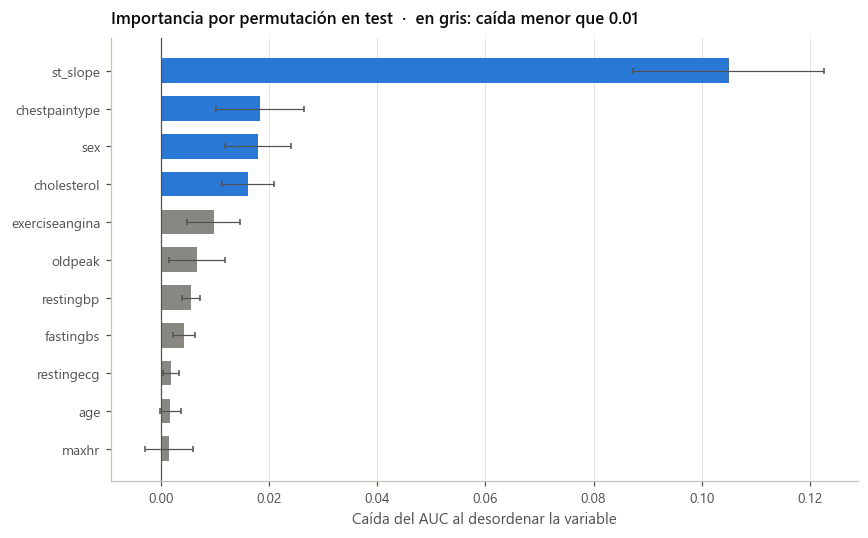

,caida_AUC_media,caida_AUC_std
ST_Slope,0.1050,0.0176
ChestPainType,0.0184,0.0082
Sex,0.0179,0.0061
Cholesterol,0.0161,0.0048
ExerciseAngina,0.0098,0.0049
Oldpeak,0.0067,0.0052
RestingBP,0.0056,0.0017
FastingBS,0.0044,0.0021
RestingECG,0.0019,0.0015
Age,0.0018,0.0020


In [14]:
imp = permutation_importance(modelo_final, X_test, y_test, scoring="roc_auc", n_repeats=30, random_state=SEED, n_jobs=-1)
importancias = (pd.DataFrame({"caida_AUC_media": imp.importances_mean, "caida_AUC_std": imp.importances_std},
                             index=X_test.columns).sort_values("caida_AUC_media"))

fig, ax = plt.subplots(figsize=(8, 5))
colores = np.where(importancias["caida_AUC_media"] > 0.01, COLOR["principal"], COLOR["tenue"])
ax.barh(importancias.index.str.lower(), importancias["caida_AUC_media"], xerr=importancias["caida_AUC_std"],
        color=colores, height=0.65, error_kw=dict(ecolor=COLOR["texto_2"], capsize=2, linewidth=0.8))
ax.axvline(0, color=COLOR["texto_2"], linewidth=0.8)
ax.set_xlabel("Caída del AUC al desordenar la variable")
ax.grid(axis="y", visible=False)
ax.set_title("Importancia por permutación en test  ·  en gris: caída menor que 0.01")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_importancia_permutacion.png")
plt.show()
display(importancias.sort_values("caida_AUC_media", ascending=False).style.format("{:.4f}"))

st_slope es la variable más importante: desordenarla hace caer el AUC en 0.105. Le siguen chestpaintype (0.018), sex (0.018) y cholesterol (0.016). Coincide con el EDA, donde st_slope tuvo la mayor V de Cramér (0.62).

Hay dos resultados que se explican por cómo funciona la permutación:

1. cholesterol aparece más importante que en el EDA, donde tenía un efecto pequeño. Al desordenarla también se desordenan los ceros, y con ellos el indicador de faltante, que según la Parte 24 del notebook 1 está muy asociado con la enfermedad. Buena parte de su importancia es la del indicador, es decir, la del hospital de origen, y no la del colesterol en sí.
2. maxhr, age y oldpeak salen poco importantes aunque en el EDA separaban bien las clases. Están correlacionadas con st_slope, exerciseangina y chestpaintype (Parte 22 del notebook 1). Al desordenar una de ellas, el bosque sigue teniendo la misma información en las otras, así que la permutación subestima la importancia de las variables redundantes.

Parte 11. Exportación del modelo

Se guarda el Pipeline completo (preprocesador + clasificador), tal como indica el enunciado:

joblib.dump(grid.best_estimator_, "app/model.joblib")

La ruta es relativa a la raíz del proyecto, porque la API se ejecuta desde ahí. Junto al modelo se guarda un archivo de metadatos con el orden y los valores válidos de las variables, las métricas y la versión de scikit-learn. Un modelo guardado con joblib solo se puede cargar de forma confiable con la misma versión de scikit-learn, así que esa versión se fijará en docker/requirements.txt.

In [15]:
APP_DIR.mkdir(exist_ok=True)
ruta_modelo = APP_DIR / "model.joblib"
joblib.dump(grid.best_estimator_, ruta_modelo)

metadatos = {
    "modelo": type(modelo_final.named_steps["clf"]).__name__,
    "hiperparametros": {k.replace("clf__", ""): (v if isinstance(v, (int, float, str, type(None))) else str(v))
                        for k, v in grid.best_params_.items() if k != "clf"},
    "columnas_entrada": COLUMNAS_ENTRADA,
    "categorias": {c: sorted(X_train[c].unique().tolist()) for c in COLS_ONEHOT},
    # Rango observado en train (sin los ceros imposibles); sirve para validar entradas en la API
    "rangos_train": {c: [float(X_train.loc[X_train[c] != 0, c].min() if c in COLS_CEROS else X_train[c].min()),
                         float(X_train[c].max())] for c in COLS_ESCALAR + COLS_CEROS},
    "umbral": 0.5,
    "umbral_youden": round(umbral_youden, 4),
    "auc_cv": round(float(grid.best_score_), 4),
    "auc_cv_anidado": round(float(anidada["test_roc_auc"].mean()), 4),
    "metricas_test": {k: round(float(v), 4) for k, v in metricas_test.items()},
    "sklearn_version": sklearn.__version__,
    "fecha_entrenamiento": time.strftime("%Y-%m-%d"),
}
(APP_DIR / "model_metadata.json").write_text(json.dumps(metadatos, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Modelo guardado   : {ruta_modelo} ({ruta_modelo.stat().st_size / 1e3:.1f} KB)")
print(f"Metadatos guardados: {APP_DIR / 'model_metadata.json'}")
print(json.dumps(metadatos, indent=2, ensure_ascii=False))

Modelo guardado   : E:\Documents\MachineLearningUN\heart-disease-mlops\app\model.joblib (2222.7 KB)
Metadatos guardados: E:\Documents\MachineLearningUN\heart-disease-mlops\app\model_metadata.json
{
  "modelo": "RandomForestClassifier",
  "hiperparametros": {
    "max_depth": null,
    "max_features": "sqrt",
    "min_samples_leaf": 5
  },
  "columnas_entrada": [
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "RestingECG",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope"
  ],
  "categorias": {
    "Sex": [
      "F",
      "M"
    ],
    "ChestPainType": [
      "ASY",
      "ATA",
      "NAP",
      "TA"
    ],
    "RestingECG": [
      "LVH",
      "Normal",
      "ST"
    ],
    "ExerciseAngina": [
      "N",
      "Y"
    ],
    "ST_Slope": [
      "Down",
      "Flat",
      "Up"
    ]
  },
  "rangos_train": {
    "Age": [
      29.0,
      77.0
    ],
    "MaxHR": [
      60.0,
      202.0
    ],
    "Oldpeak": [

Verificación: cargar el modelo y predecir un paciente nuevo, como lo hará la API

In [16]:
modelo_cargado = joblib.load(ruta_modelo)

# Las predicciones del modelo cargado son idénticas a las del modelo en memoria
assert np.allclose(modelo_cargado.predict_proba(X_test)[:, 1], proba_test)
print("El modelo cargado reproduce exactamente las probabilidades de test.")

# Paciente de ejemplo con los datos crudos (incluido un colesterol en 0, que el Pipeline trata como faltante)
paciente = pd.DataFrame([{
    "Age": 58, "Sex": "M", "ChestPainType": "ASY", "RestingBP": 140, "Cholesterol": 0,
    "FastingBS": 1, "RestingECG": "ST", "MaxHR": 110, "ExerciseAngina": "Y", "Oldpeak": 2.0, "ST_Slope": "Flat",
}])[COLUMNAS_ENTRADA]
proba = modelo_cargado.predict_proba(paciente)[0, 1]
print(f"Probabilidad de enfermedad cardíaca: {proba:.3f} -> predicción: {int(proba > 0.5)}")

El modelo cargado reproduce exactamente las probabilidades de test.
Probabilidad de enfermedad cardíaca: 0.985 -> predicción: 1


# Conclusiones de la Etapa 2

1. Datos: el split estratificado 80/20 se hizo antes de cualquier escalado o imputación. Train y test quedaron guardados en data/ para el monitoreo de la Etapa 6.
2. Pipeline: el modelo exportado incluye todo el preprocesamiento. Los ceros imposibles se tratan con SimpleImputer(missing_values=0), así que el modelo recibe los datos crudos del paciente.
3. Selección: un solo GridSearchCV comparó 5 modelos y 90 combinaciones con los mismos folds. Ganó RandomForest (AUC CV = 0.934), empatado en la práctica con GradientBoosting (p = 0.304). La validación anidada estima el rendimiento real del procedimiento en AUC = 0.926 ± 0.012.
4. Evaluación en test: AUC = 0.934 (IC 95 % 0.893–0.968), Accuracy = 0.891, sensibilidad 0.941 y especificidad 0.829, con 6 falsos negativos y 14 falsos positivos. El umbral de Youden (0.55) reduce los falsos positivos a 11.
5. Exportación: el modelo está en app/model.joblib y los metadatos en app/model_metadata.json. El modelo cargado reproduce exactamente las predicciones. Fue entrenado con scikit-learn 1.3.0, y esa versión debe fijarse en docker/requirements.txt para que la API de la Etapa 3 lo pueda cargar.